In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = image / 255.0
    return image, label
# Convert to tf.data pipeline
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
# Load pretrained model
base_model = MobileNetV2(input_shape=(96,96,3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_ds,
          epochs=5,
          validation_data=test_ds)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 24ms/step - accuracy: 0.7523 - loss: 0.7111 - val_accuracy: 0.7846 - val_loss: 0.6191
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8089 - loss: 0.5478 - val_accuracy: 0.7985 - val_loss: 0.5870
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8306 - loss: 0.4851 - val_accuracy: 0.7967 - val_loss: 0.5948
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8484 - loss: 0.4339 - val_accuracy: 0.7962 - val_loss: 0.6059
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8640 - loss: 0.3897 - val_accuracy: 0.8006 - val_loss: 0.6225


Saving Screenshot 2026-04-06 161724.png to Screenshot 2026-04-06 161724.png


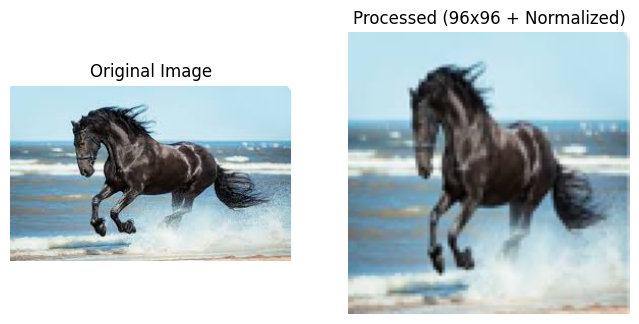

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Class: horse


In [9]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
uploaded = files.upload()
for filename in uploaded.keys():
    # Original Image
    img = Image.open(filename).convert("RGB")
    # Processed Image
    img_resized = img.resize((96,96))
    img_array = np.array(img_resized) / 255.0
    # Plot side-by-side
    plt.figure(figsize=(8,4))
    # Original
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    # Processed
    plt.subplot(1,2,2)
    plt.imshow(img_array)
    plt.title("Processed (96x96 + Normalized)")
    plt.axis("off")
    plt.show()
img_input = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_input)
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]
print("Predicted Class:", class_names[np.argmax(prediction)])

Saving Screenshot 2026-04-06 161818.png to Screenshot 2026-04-06 161818.png


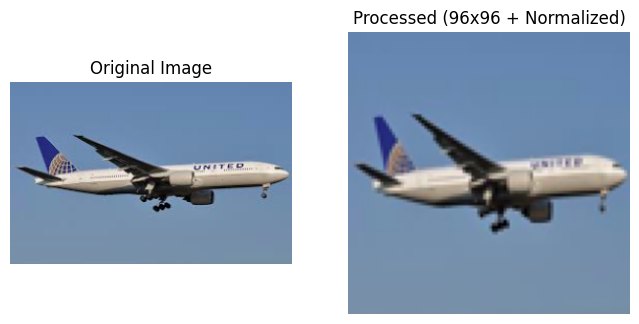

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Class: airplane
